In [17]:
import ccxt

exchange = ccxt.okx({
    "enableRateLimit": True,
})

symbol = "BTC/USDT"
timeframe = "1d"
limit = 1000

ohlcv = exchange.fetch_ohlcv(
    symbol=symbol,
    timeframe=timeframe,
    limit=limit,
)

print(type(ohlcv))
print(len(ohlcv))
print(ohlcv[0])

<class 'list'>
300
[1756339200000, 111254.1, 113484.9, 110869.6, 112564.0, 5118.99688195]


In [20]:
import pandas as pd

columns = [
    "timestamp",
    "open",
    "high",
    "low",
    "close",
    "volume",
]

df = pd.DataFrame(ohlcv, columns=columns)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    unit="ms",
    utc=True,
)

df = df.set_index("timestamp")
df = df.sort_index()

print(df.head())
print(df.tail())

                               open      high       low     close       volume
timestamp                                                                     
2025-08-28 00:00:00+00:00  111254.1  113484.9  110869.6  112564.0  5118.996882
2025-08-29 00:00:00+00:00  112564.1  112642.0  107474.9  108385.7  7323.836956
2025-08-30 00:00:00+00:00  108385.8  108922.9  107343.7  108815.0  4987.664210
2025-08-31 00:00:00+00:00  108815.1  109486.0  108064.9  108248.3  2305.232282
2025-09-01 00:00:00+00:00  108248.0  109911.0  107250.0  109235.9  4341.712476
                              open     high      low    close       volume
timestamp                                                                 
2026-06-19 00:00:00+00:00  62953.3  63664.0  62310.1  63541.0  5700.907189
2026-06-20 00:00:00+00:00  63541.0  64384.5  63200.0  64300.0  7039.788795
2026-06-21 00:00:00+00:00  64300.1  64594.0  63262.0  63313.0  6447.301976
2026-06-22 00:00:00+00:00  63313.1  65629.5  63313.1  64027.6  6066.3150

In [21]:
numeric_columns = ["open", "high", "low", "close", "volume"]
df[numeric_columns] = df[numeric_columns].astype(float)

print(df.dtypes)

open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object


In [22]:
print("开始时间：", df.index.min())
print("结束时间：", df.index.max())
print("数据行数：", len(df))

开始时间： 2025-08-28 00:00:00+00:00
结束时间： 2026-06-23 00:00:00+00:00
数据行数： 300


In [6]:
print("时间是否递增：", df.index.is_monotonic_increasing)

时间是否递增： True


In [7]:
duplicate_count = df.index.duplicated().sum()
print("重复时间数量：", duplicate_count)

重复时间数量： 0


In [8]:
print(df.isna().sum())

open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [9]:
invalid_price_rows = df[
    (df["high"] < df[["open", "close", "low"]].max(axis=1))
    | (df["low"] > df[["open", "close", "high"]].min(axis=1))
]

print("价格关系异常行数：", len(invalid_price_rows))

价格关系异常行数： 0


In [23]:
from pathlib import Path

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

file_path = data_dir / "btc_usdt_1d.csv"
df.to_csv(file_path)

print(file_path)

data/btc_usdt_1d.csv


In [11]:
df_saved = pd.read_csv(
    file_path,
    parse_dates=["timestamp"],
    index_col="timestamp",
)

print(df_saved.head())
print(df_saved.dtypes)

                              open     high      low    close       volume
timestamp                                                                 
2026-03-16 00:00:00+00:00  72806.9  74934.7  72268.3  74883.5  8939.478776
2026-03-17 00:00:00+00:00  74883.6  76011.8  73389.0  73904.2  7711.448422
2026-03-18 00:00:00+00:00  73904.3  74668.6  70500.0  71253.1  7533.380539
2026-03-19 00:00:00+00:00  71253.1  71618.0  68796.3  69923.7  7331.205854
2026-03-20 00:00:00+00:00  69923.7  71366.0  69393.5  70515.7  5670.280110
open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object


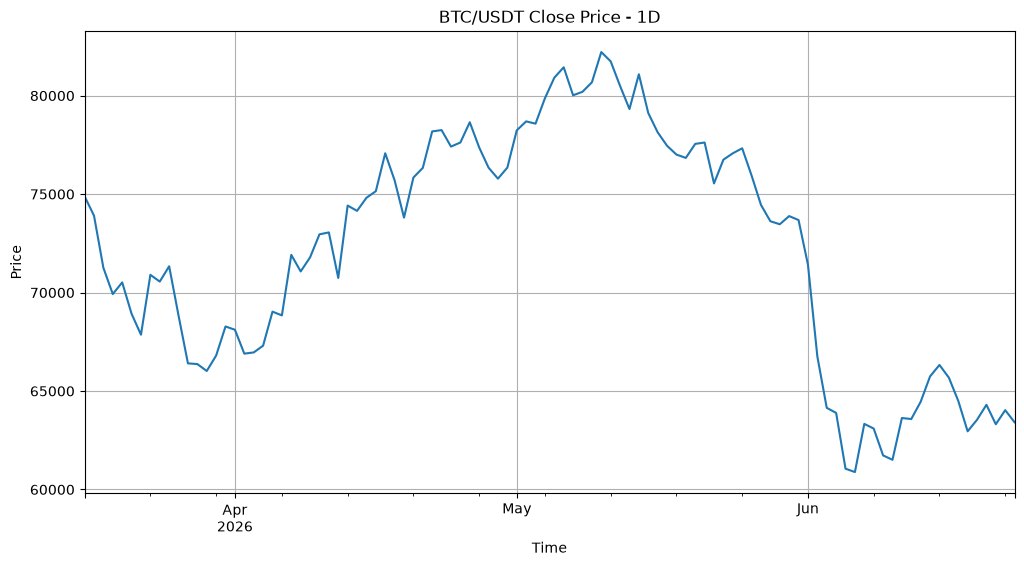

In [12]:
import matplotlib.pyplot as plt

ax = df["close"].plot(
    figsize=(12, 6),
    title="BTC/USDT Close Price - 1D",
)

ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True)

plt.show()

In [13]:
df["return"] = df["close"].pct_change(fill_method=None)

print(df[["close", "return"]].tail())

                             close    return
timestamp                                   
2026-06-19 00:00:00+00:00  63541.0  0.009335
2026-06-20 00:00:00+00:00  64300.0  0.011945
2026-06-21 00:00:00+00:00  63313.0 -0.015350
2026-06-22 00:00:00+00:00  64027.6  0.011287
2026-06-23 00:00:00+00:00  63412.1 -0.009613


In [14]:
df["growth"] = (1 + df["return"].fillna(0)).cumprod()
df["cumulative_return"] = df["growth"] - 1

final_return = df["cumulative_return"].iloc[-1]

print(f"BTC 买入持有收益率：{final_return:.2%}")

BTC 买入持有收益率：-15.32%


In [15]:
equity = df["growth"]
historical_peak = equity.cummax()
drawdown = equity / historical_peak - 1

max_drawdown = drawdown.min()
trough_time = drawdown.idxmin()
peak_time = equity.loc[:trough_time].idxmax()

print(f"最大回撤：{max_drawdown:.2%}")
print(f"回撤高点：{peak_time}")
print(f"回撤低点：{trough_time}")

最大回撤：-25.94%
回撤高点：2026-05-10 00:00:00+00:00
回撤低点：2026-06-06 00:00:00+00:00


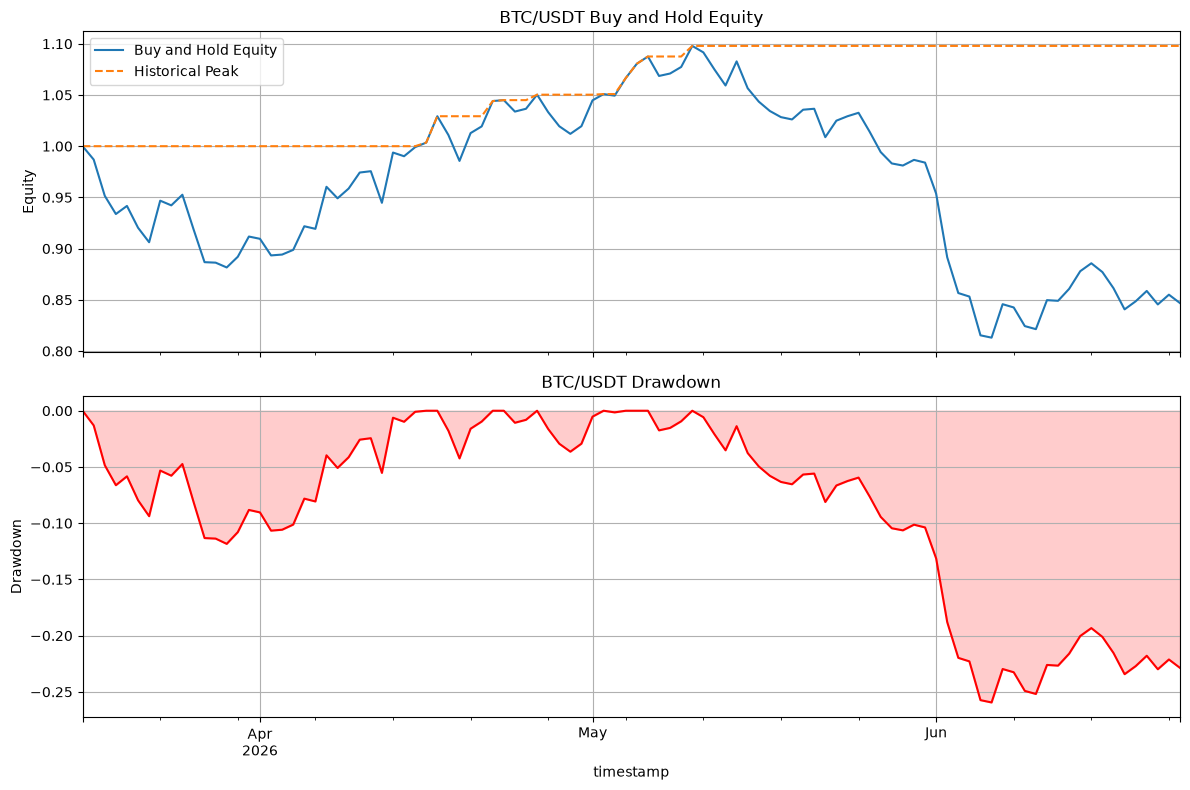

In [16]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
)

equity.plot(
    ax=axes[0],
    label="Buy and Hold Equity",
)

historical_peak.plot(
    ax=axes[0],
    linestyle="--",
    label="Historical Peak",
)

axes[0].set_title("BTC/USDT Buy and Hold Equity")
axes[0].set_ylabel("Equity")
axes[0].legend()
axes[0].grid(True)

drawdown.plot(
    ax=axes[1],
    color="red",
)

axes[1].fill_between(
    drawdown.index,
    drawdown.values,
    0,
    color="red",
    alpha=0.2,
)

axes[1].set_title("BTC/USDT Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].grid(True)

plt.tight_layout()
plt.show()